# Automotive Complaint Intelligence: NLP Classification and Early-Warning Analysis

## Project Goal

Build an automotive complaint-intelligence pipeline using NHTSA consumer complaint narratives for five selected 2021 vehicle models. The project aims to:

1. Classify a complaint narrative into its reported vehicle component.
2. Track monthly complaint volumes by vehicle and component.
3. Flag unusual increases that may warrant further safety investigation.
4. Examine recurring language within high-priority warning periods.

## Main Question

Can NHTSA complaint narratives be used to automatically classify reported vehicle components and identify vehicle-specific increases in complaint volume that should be investigated?

## Case Study

The analysis examines 2021 Honda Accord, Toyota Camry, Ford Explorer, Tesla Model 3, and Hyundai Elantra complaints. It is a selected-vehicle case study, not a comparison of every 2021 vehicle sold in the United States.

In [ ]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import time

In [ ]:
vehicles = [
    {"make": "Honda", "model": "Accord", "year": 2021},
    {"make": "Toyota", "model": "Camry", "year": 2021},
    {"make": "Ford", "model": "Explorer", "year": 2021},
    {"make": "Tesla", "model": "Model 3", "year": 2021},
    {"make": "Hyundai", "model": "Elantra", "year": 2021}
]

all_complaints = []

for vehicle in vehicles:
    response = requests.get(
        "https://api.nhtsa.gov/complaints/complaintsByVehicle",
        params={
            "make": vehicle["make"],
            "model": vehicle["model"],
            "modelYear": vehicle["year"]
        },
        timeout=30
    )

    print(
        vehicle["make"],
        vehicle["model"],
        vehicle["year"],
        "| Status:",
        response.status_code
    )

    results = response.json().get("results", [])

    for complaint in results:
        complaint["searched_make"] = vehicle["make"]
        complaint["searched_model"] = vehicle["model"]
        complaint["searched_year"] = vehicle["year"]
        all_complaints.append(complaint)

    time.sleep(1)

df = pd.DataFrame(all_complaints)

print("\nTotal complaints collected:", len(df))
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

df.to_csv("nhtsa_vehicle_complaints.csv", index=False)

Honda Accord 2021 | Status: 200
Toyota Camry 2021 | Status: 200
Ford Explorer 2021 | Status: 200
Tesla Model 3 2021 | Status: 200
Hyundai Elantra 2021 | Status: 200

Total complaints collected: 1617

Columns:
['odiNumber', 'manufacturer', 'crash', 'fire', 'numberOfInjuries', 'numberOfDeaths', 'dateOfIncident', 'dateComplaintFiled', 'vin', 'components', 'summary', 'products', 'searched_make', 'searched_model', 'searched_year']


,odiNumber,manufacturer,crash,fire,numberOfInjuries,numberOfDeaths,dateOfIncident,dateComplaintFiled,vin,components,summary,products,searched_make,searched_model,searched_year
0,11767316,Honda (American Honda Motor Co.),False,False,0,0,02/24/2026,09/28/2026,1HGCV1F37MA,"ELECTRICAL SYSTEM,ENGINE",Active Turbocharger Boost Control Position Sen...,"[{'type': 'Vehicle', 'productYear': '2021', 'p...",Honda,Accord,2021
1,11767198,Honda (American Honda Motor Co.),False,False,0,0,03/03/2026,09/26/2026,1HGCV2F32MA,ELECTRICAL SYSTEM,The infotainment/touchscreen system in my 2021...,"[{'type': 'Vehicle', 'productYear': '2021', 'p...",Honda,Accord,2021
2,11766324,Honda (American Honda Motor Co.),False,False,0,0,08/01/2026,09/23/2026,1HGCV1F17MA,ENGINE AND ENGINE COOLING,The contact owns a 2021 Honda Accord. The cont...,"[{'type': 'Vehicle', 'productYear': '2021', 'p...",Honda,Accord,2021
3,11765567,Honda (American Honda Motor Co.),False,False,0,0,08/13/2026,09/19/2026,1HGCV2F30MA,FORWARD COLLISION AVOIDANCE,Sudden braking; car comes to a complete stop a...,"[{'type': 'Vehicle', 'productYear': '2021', 'p...",Honda,Accord,2021
4,11764287,Honda (American Honda Motor Co.),False,False,0,0,09/10/2026,09/15/2026,1HGCV1F13MA,UNKNOWN OR OTHER,COMPONENT: Visibility--Exterior Rearview Mirro...,"[{'type': 'Vehicle', 'productYear': '2021', 'p...",Honda,Accord,2021


Some complaints have more than one component (for example, ELECTRICAL SYSTEM,ENGINE). For now, let us use only complaints with one component so this stays a clear multiclass classification project.

In [ ]:
# Basic data-quality check
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

# Count how many official component labels each complaint has
df["number_of_components"] = (
    df["components"]
    .fillna("")
    .str.count(",")
    .add(1)
)

print("\nNumber of components per complaint:")
print(df["number_of_components"].value_counts().sort_index())

# Most common component labels
print("\nMost common component combinations:")
print(df["components"].value_counts().head(20))

# Check whether complaint text sometimes explicitly contains a component label
print("\nExamples of complaint narratives:")
display(
    df[["components", "summary"]]
    .sample(10, random_state=42)
)

Dataset shape: (1617, 15)

Missing values:
vin                   8
manufacturer          0
odiNumber             0
fire                  0
numberOfInjuries      0
numberOfDeaths        0
crash                 0
dateOfIncident        0
dateComplaintFiled    0
components            0
summary               0
products              0
searched_make         0
searched_model        0
searched_year         0
dtype: int64

Number of components per complaint:
number_of_components
1    1048
2     388
3     179
4       1
7       1
Name: count, dtype: int64

Most common component combinations:
components
FORWARD COLLISION AVOIDANCE                                         258
UNKNOWN OR OTHER                                                    151
POWER TRAIN                                                         104
AIR BAGS                                                             86
ELECTRICAL SYSTEM                                                    75
SERVICE BRAKES,FORWARD COLLISION AVOIDANCE

,components,summary
135,LANE DEPARTURE,Lane centering continue to jerk the wheel so h...
478,EXTERIOR LIGHTING,LED low beam headlight failures. Our 1st headl...
1193,ELECTRICAL SYSTEM,The contact owns a Tesla Unavailable. The cont...
566,"ELECTRICAL SYSTEM,VISIBILITY/WIPER",Sun shade sagging. Causing loss of visibility.
626,BACK OVER PREVENTION,The contact owns a 2021 Ford Explorer. The con...
1164,"VEHICLE SPEED CONTROL,SERVICE BRAKES,FORWARD C...",While driving at 70 mph with adaptive cruise c...
1586,SEAT BELTS,The contact owns a 2021 Hyundai Elantra. The c...
810,"SERVICE BRAKES, HYDRAULIC","Vibration: First use of the day, at about 35 ..."
1107,"VEHICLE SPEED CONTROL,FORWARD COLLISION AVOIDANCE",Driving with cruise control on following anoth...
271,AIR BAGS,Manufacturer Recall Number23TB15 NHTSA Recall ...


In [ ]:
# Keep only complaints with one official component label
single_component_df = df[
    df["number_of_components"] == 1
].copy()

# The target the model will predict
single_component_df["target"] = (
    single_component_df["components"]
    .str.strip()
    .str.upper()
)

# Keep categories with enough examples for a fair train/test split
component_counts = single_component_df["target"].value_counts()

eligible_components = component_counts[
    component_counts >= 30
].index

model_df = single_component_df[
    single_component_df["target"].isin(eligible_components)
].copy()

print("Single-component complaints:", len(single_component_df))
print("Complaints retained for Version 1:", len(model_df))
print("Number of component classes:", model_df["target"].nunique())

print("\nComponent classes used for modelling:")
print(model_df["target"].value_counts())

# Check for obvious label leakage in the narrative text
component_marker_count = model_df["summary"].str.contains(
    r"\bCOMPONENT\s*:",
    case=False,
    na=False,
    regex=True
).sum()

print("\nNarratives containing 'COMPONENT:':", component_marker_count)

Single-component complaints: 1048
Complaints retained for Version 1: 860
Number of component classes: 10

Component classes used for modelling:
target
FORWARD COLLISION AVOIDANCE    258
UNKNOWN OR OTHER               151
POWER TRAIN                    104
AIR BAGS                        86
ELECTRICAL SYSTEM               75
ENGINE                          51
VISIBILITY/WIPER                37
SEAT BELTS                      34
STRUCTURE                       33
SERVICE BRAKES                  31
Name: count, dtype: int64

Narratives containing 'COMPONENT:': 2


Only two narratives explicitly contain 'COMPONENT:,'. Let us drop them to prevent leakage. We do this by cleaning the respective cells.

In [ ]:
import re

# Remove the two rows where the answer may be written in the text
model_df = model_df[
    ~model_df["summary"].str.contains(
        r"\bCOMPONENT\s*:",
        case=False,
        na=False,
        regex=True
    )
].copy()

# Create a cleaned version of each complaint narrative
model_df["clean_text"] = (
    model_df["summary"]
    .str.lower()
    .str.replace(r"[^a-z\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Remove any rows that became empty after cleaning
model_df = model_df[model_df["clean_text"].str.len() > 0].copy()

print("Final modelling dataset shape:", model_df.shape)

display(
    model_df[["target", "summary", "clean_text"]]
    .sample(5, random_state=42)
)

Final modelling dataset shape: (858, 18)


,target,summary,clean_text
1357,FORWARD COLLISION AVOIDANCE,This has happened frequently since I took deli...,this has happened frequently since i took deli...
1134,UNKNOWN OR OTHER,Heating failure in colder temperature climates...,heating failure in colder temperature climates...
226,FORWARD COLLISION AVOIDANCE,The contact owns a 2021 Honda Acord. The conta...,the contact owns a honda acord the contact sta...
339,AIR BAGS,The contact's wife owns a 2021 Toyota Camry. T...,the contact s wife owns a toyota camry the con...
641,POWER TRAIN,"25,000 miles on it, transmission failed on my ...",miles on it transmission failed on my husband ...


Let us now visualize our data.

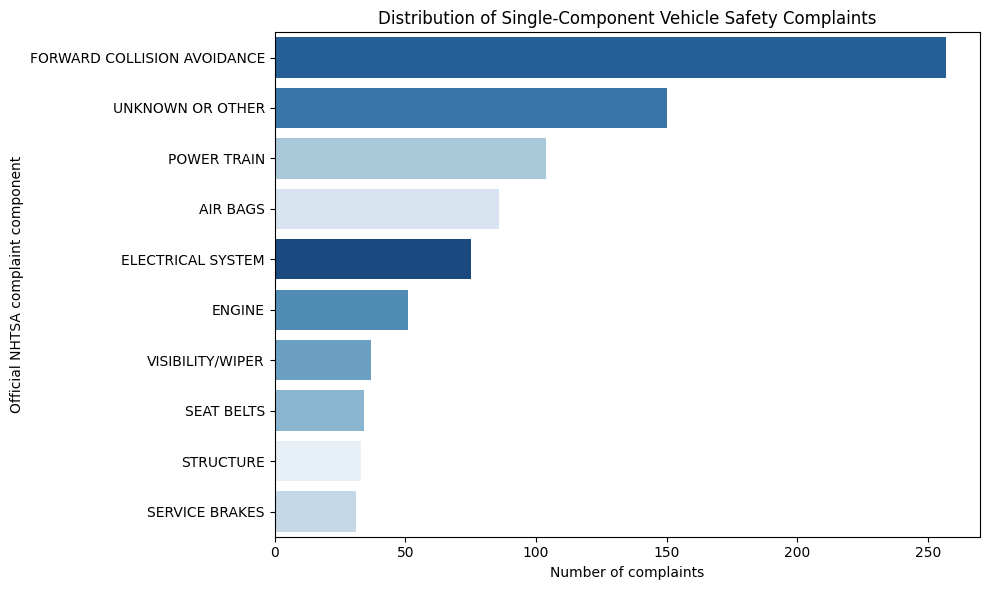

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.countplot(
    data=model_df,
    y="target",
    order=model_df["target"].value_counts().index,
    hue="target",
    legend=False,
    palette="Blues_r"
)

plt.title("Distribution of Single-Component Vehicle Safety Complaints")
plt.xlabel("Number of complaints")
plt.ylabel("Official NHTSA complaint component")

plt.tight_layout()
plt.show()

We can see a clear patter above. 'Forward Collision Avoidance' is much more common compared to 'Service Brakes.'

**The main point: The data is imbalanced. **

In [ ]:
from sklearn.model_selection import train_test_split

# X = the complaint narratives the model reads
X = model_df["clean_text"]

# y = the official component the model must predict
y = model_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training-text rows:", X_train.shape[0])
print("Test-text rows:", X_test.shape[0])

print("\nTraining-set component distribution:")
print(y_train.value_counts())

print("\nTest-set component distribution:")
print(y_test.value_counts())

Training-text rows: 686
Test-text rows: 172

Training-set component distribution:
target
FORWARD COLLISION AVOIDANCE    205
UNKNOWN OR OTHER               120
POWER TRAIN                     83
AIR BAGS                        69
ELECTRICAL SYSTEM               60
ENGINE                          41
VISIBILITY/WIPER                30
SEAT BELTS                      27
STRUCTURE                       26
SERVICE BRAKES                  25
Name: count, dtype: int64

Test-set component distribution:
target
FORWARD COLLISION AVOIDANCE    52
UNKNOWN OR OTHER               30
POWER TRAIN                    21
AIR BAGS                       17
ELECTRICAL SYSTEM              15
ENGINE                         10
STRUCTURE                       7
SEAT BELTS                      7
VISIBILITY/WIPER                7
SERVICE BRAKES                  6
Name: count, dtype: int64


We use 'stratify=y' to ensure every component appears in both the training, and test datasets in roughly the same proportion.
Without it, a small category such as SERVICE BRAKES might barely appear or worse, not appear at all in the test set.

This is not ideal. We are preparing this data for TF-IDF.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Pipeline keeps text transformation and model training together.
# This prevents the vectorizer from learning anything from the test dataset.
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_features=10_000
    )),

    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

# Learn from the training complaints only
baseline_model.fit(X_train, y_train)

# Predict the official component for unseen test complaints
y_pred = baseline_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Macro F1-score:", round(f1_score(y_test, y_pred, average="macro"), 3))

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.744
Macro F1-score: 0.659

Detailed classification report:
                             precision    recall  f1-score   support

                   AIR BAGS       0.87      0.76      0.81        17
          ELECTRICAL SYSTEM       0.43      0.40      0.41        15
                     ENGINE       1.00      0.70      0.82        10
FORWARD COLLISION AVOIDANCE       0.94      0.92      0.93        52
                POWER TRAIN       0.76      0.90      0.83        21
                 SEAT BELTS       1.00      1.00      1.00         7
             SERVICE BRAKES       0.40      0.33      0.36         6
                  STRUCTURE       0.40      0.29      0.33         7
           UNKNOWN OR OTHER       0.57      0.70      0.63        30
           VISIBILITY/WIPER       0.50      0.43      0.46         7

                   accuracy                           0.74       172
                  macro avg       0.69      0.64      0.66       172
               weighted avg   

We can see the following:

Accuracy: 74.4%
Macro F1: 65.9%

The model is strong on large, distinct categories such as Forward Collision Avoidance and Power Train, but weaker on smaller or vaguer categories like Service Brakes, Structure, and Electrical System.

PS - f1-score for seatbelts is 1. This looks concerning at first, until we remember that there are only 7 test examples of that. The result is not as reliable as the larger categories.

Our next goal is to identify where the model is confusing its categories.

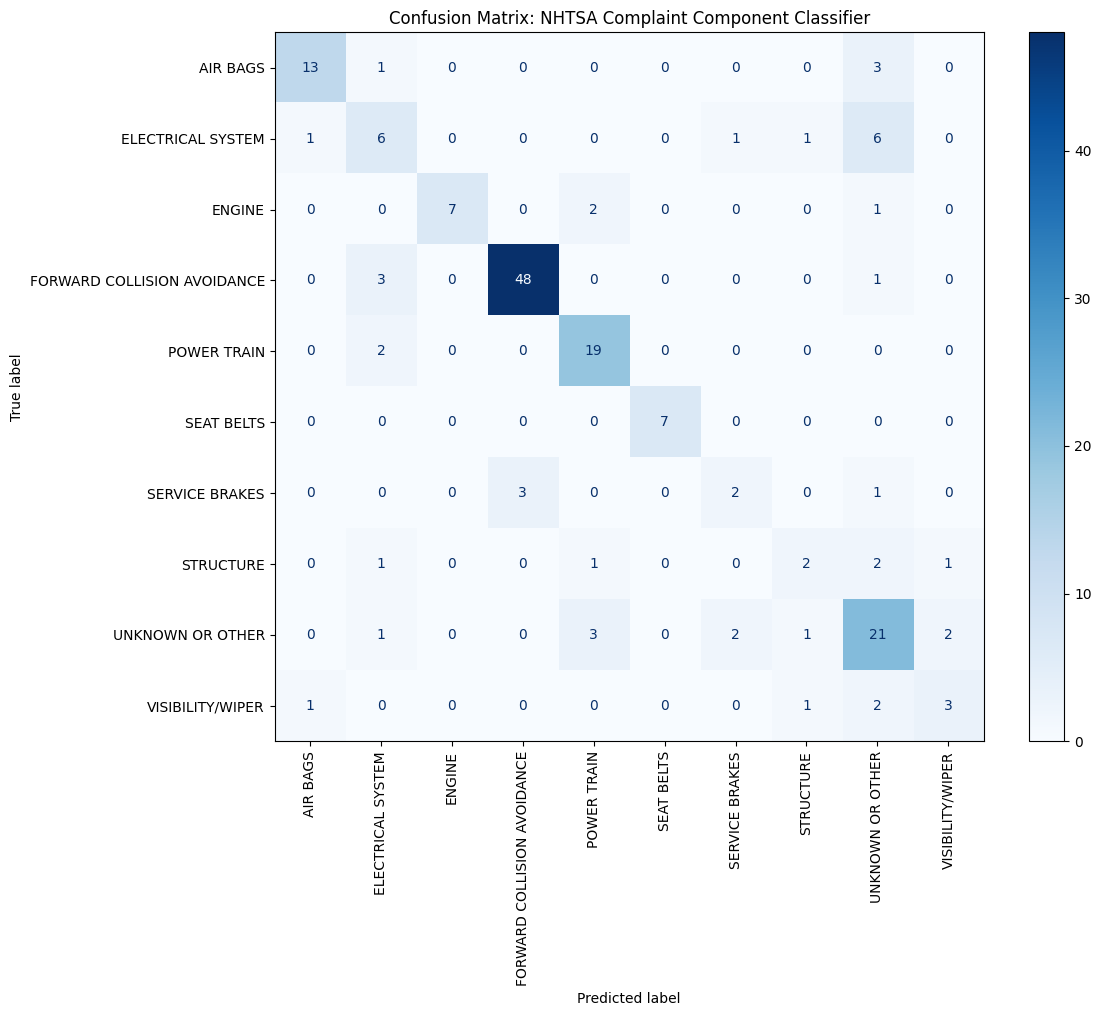

Number of misclassified complaints: 44


,complaint_text,actual_component,predicted_component
142,heating core on car has gone out times the fir...,ENGINE,UNKNOWN OR OTHER
79,just quit working after being adjusted still n...,FORWARD COLLISION AVOIDANCE,ELECTRICAL SYSTEM
81,the drivers side door latch mechanism malfunct...,UNKNOWN OR OTHER,STRUCTURE
140,the panel next the windows on both sides are c...,STRUCTURE,UNKNOWN OR OTHER
125,i have a ford explorer st that i purchased as ...,UNKNOWN OR OTHER,POWER TRAIN
155,the contact owns a ford explorer the contact s...,AIR BAGS,ELECTRICAL SYSTEM
14,the contact leases a ford explorer the contact...,FORWARD COLLISION AVOIDANCE,ELECTRICAL SYSTEM
44,my car randomly slams on the breaks with no on...,SERVICE BRAKES,FORWARD COLLISION AVOIDANCE
36,sunroof shade has fallen off tracks while driving,UNKNOWN OR OTHER,VISIBILITY/WIPER
8,front windshield cracked n has expanded along ...,STRUCTURE,VISIBILITY/WIPER


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Confusion matrix: rows are actual components, columns are predicted components
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=baseline_model.classes_,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix: NHTSA Complaint Component Classifier")
plt.tight_layout()
plt.show()

# Create a table of complaints the model got wrong
errors_df = pd.DataFrame({
    "complaint_text": X_test.to_numpy(),
    "actual_component": y_test.to_numpy(),
    "predicted_component": y_pred
})

errors_df = errors_df[
    errors_df["actual_component"] != errors_df["predicted_component"]
].copy()

print("Number of misclassified complaints:", len(errors_df))

display(
    errors_df.sample(
        min(15, len(errors_df)),
        random_state=42
    )
)

In [ ]:
# Convert complaint-filed date from text into an actual date type
trend_df = model_df.copy()

trend_df["complaint_date"] = pd.to_datetime(
    trend_df["dateComplaintFiled"],
    format="%m/%d/%Y",
    errors="coerce"
)

print("Missing converted dates:", trend_df["complaint_date"].isna().sum())

print("Earliest complaint date:", trend_df["complaint_date"].min())
print("Latest complaint date:", trend_df["complaint_date"].max())

# Create a month column for trend analysis
trend_df["complaint_month"] = (
    trend_df["complaint_date"]
    .dt.to_period("M")
    .astype(str)
)

# Count complaints by month and component
monthly_component_counts = (
    trend_df
    .groupby(["complaint_month", "target"])
    .size()
    .reset_index(name="complaint_count")
)

display(monthly_component_counts.head(15))

Missing converted dates: 0
Earliest complaint date: 2021-02-03 00:00:00
Latest complaint date: 2026-09-29 00:00:00


,complaint_month,target,complaint_count
0,2021-02,UNKNOWN OR OTHER,3
1,2021-03,UNKNOWN OR OTHER,1
2,2021-04,ELECTRICAL SYSTEM,1
3,2021-05,POWER TRAIN,1
4,2021-06,FORWARD COLLISION AVOIDANCE,1
5,2021-06,POWER TRAIN,1
6,2021-06,SEAT BELTS,1
7,2021-06,STRUCTURE,1
8,2021-06,UNKNOWN OR OTHER,1
9,2021-07,ENGINE,1


Let us create the trend chart for the three most common components. It will help us see whether complaint volumes have changed over time across the five selected vehicles from 2021.

**Across these five 2021 vehicles, how many complaints in each of the three most common component categories were filed each month over this period?(i.e. next five years)**

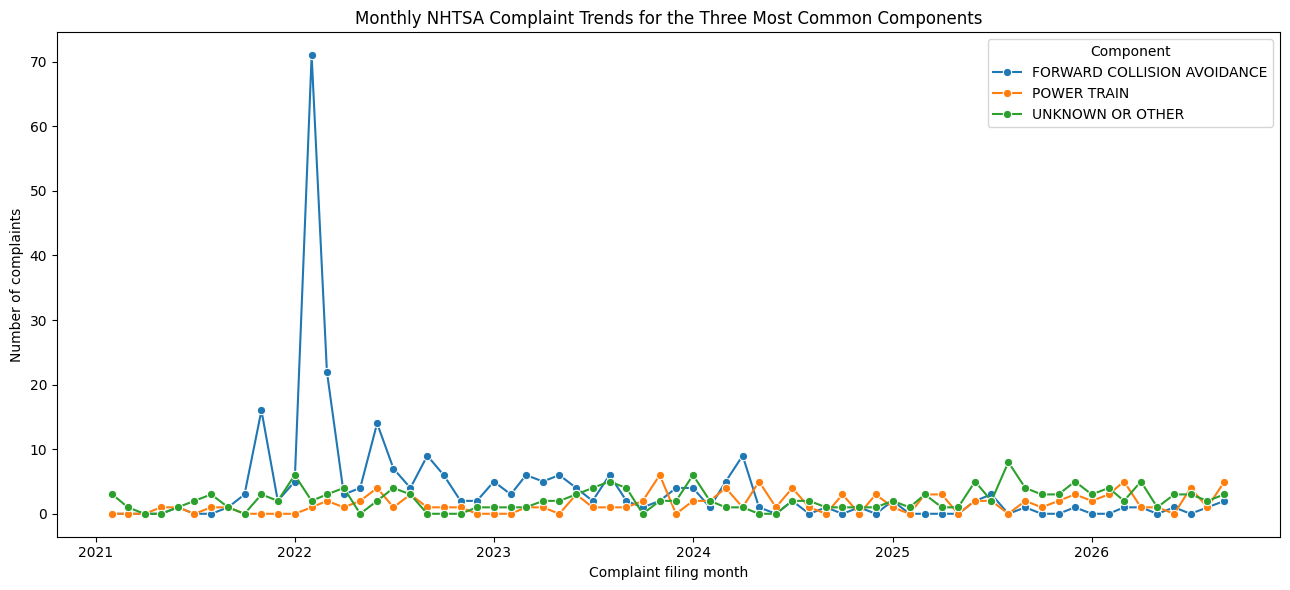

In [ ]:
# Use the three largest component categories
top_3_components = model_df["target"].value_counts().head(3).index

# Create a complete monthly timeline, including months with zero complaints
all_months = pd.date_range(
    start=trend_df["complaint_date"].min().replace(day=1),
    end=trend_df["complaint_date"].max().replace(day=1),
    freq="MS"
)

monthly_pivot = (
    trend_df[
        trend_df["target"].isin(top_3_components)
    ]
    .groupby([
        pd.Grouper(key="complaint_date", freq="MS"),
        "target"
    ])
    .size()
    .unstack(fill_value=0)
    .reindex(all_months, fill_value=0)
)

# Convert from wide format to chart-friendly long format
monthly_plot_df = (
    monthly_pivot
    .reset_index(names="complaint_month")
    .melt(
        id_vars="complaint_month",
        var_name="component",
        value_name="complaint_count"
    )
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=monthly_plot_df,
    x="complaint_month",
    y="complaint_count",
    hue="component",
    marker="o"
)

plt.title(
    "Monthly NHTSA Complaint Trends for the Three Most Common Components"
)
plt.xlabel("Complaint filing month")
plt.ylabel("Number of complaints")
plt.legend(title="Component")
plt.tight_layout()
plt.show()

FYI, here are the vehicle models from 2021 that we are examining in the above chart pooling complaints over time:

- Honda Accord
- Toyota Camry
- Ford Explorer
- Tesla Model 3
- Hyundai Elantra

The above chart shows us a big spike in Forward collision avoidance. Let us uncover which vehicle is causing that spike.

Note: A spike in these types of cases should be treated as a signal to investigate more and not just an increase in faults/problems. Sometimes spikes can be attributed to delays in filing a complaint, lack of awareness of a problem, etc.

In [ ]:
spike_month = pd.Timestamp("2022-02-01")

spike_breakdown = (
    trend_df[
        (trend_df["complaint_date"].dt.to_period("M") == spike_month.to_period("M"))
        & (trend_df["target"] == "FORWARD COLLISION AVOIDANCE")
    ]
    .groupby(["searched_make", "searched_model", "searched_year"])
    .size()
    .reset_index(name="complaint_count")
    .sort_values("complaint_count", ascending=False)
)

spike_breakdown

,searched_make,searched_model,searched_year,complaint_count
1,Tesla,Model 3,2021,70
0,Ford,Explorer,2021,1


We see that the spike is being caused by the Tesla model 3.

These are recorded complaints, rather than failures(failures divided over no. of cars on the road). So does not prove a defect risk.

Still, it is interesting and the type of pattern a model should flag.

Let us create a vehicle specific table.

This will help us see a month only when a car has at least 3 complaints and is at least twice that vehicle-component’s prior three-month average.

In [18]:
# Create a readable identifier for each vehicle
trend_df["vehicle"] = (
    trend_df["searched_make"] + " " +
    trend_df["searched_model"] + " " +
    trend_df["searched_year"].astype(str)
)

# Create a complete monthly timeline
all_months = pd.date_range(
    start=trend_df["complaint_date"].min().replace(day=1),
    end=trend_df["complaint_date"].max().replace(day=1),
    freq="MS"
)

# Count complaints for each vehicle, component, and month
vehicle_monthly_counts = (
    trend_df
    .groupby([
        "vehicle",
        "target",
        pd.Grouper(key="complaint_date", freq="MS")
    ])
    .size()
    .rename("complaint_count")
    .reset_index()
)

# Add zero-complaint months, so comparisons are fair
full_index = pd.MultiIndex.from_product(
    [
        trend_df["vehicle"].unique(),
        trend_df["target"].unique(),
        all_months
    ],
    names=["vehicle", "target", "complaint_date"]
)

vehicle_monthly = (
    vehicle_monthly_counts
    .set_index(["vehicle", "target", "complaint_date"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Calculate the average complaint count in the PREVIOUS three months
vehicle_monthly["previous_3_month_average"] = (
    vehicle_monthly
    .groupby(["vehicle", "target"])["complaint_count"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=3).mean())
)

# Compare the current month with that previous baseline
vehicle_monthly["increase_vs_baseline"] = (
    vehicle_monthly["complaint_count"] /
    vehicle_monthly["previous_3_month_average"]
)

# Our simple early-warning rule
warning_candidates = vehicle_monthly[
    (vehicle_monthly["complaint_count"] >= 3) &
    (vehicle_monthly["previous_3_month_average"] >= 1) &
    (vehicle_monthly["increase_vs_baseline"] >= 2)
].sort_values("increase_vs_baseline", ascending=False)

warning_candidates[
    [
        "vehicle",
        "target",
        "complaint_date",
        "complaint_count",
        "previous_3_month_average",
        "increase_vs_baseline"
    ]
]

,vehicle,target,complaint_date,complaint_count,previous_3_month_average,increase_vs_baseline
2117,Tesla Model 3 2021,FORWARD COLLISION AVOIDANCE,2021-11-01,16,1.000000,16.000000
2120,Tesla Model 3 2021,FORWARD COLLISION AVOIDANCE,2022-02-01,70,7.333333,9.545455
3078,Hyundai Elantra 2021,SEAT BELTS,2022-08-01,8,1.000000,8.000000
1526,Ford Explorer 2021,UNKNOWN OR OTHER,2023-08-01,4,1.000000,4.000000
1554,Ford Explorer 2021,UNKNOWN OR OTHER,2025-12-01,5,1.333333,3.750000
64,Honda Accord 2021,ELECTRICAL SYSTEM,2026-06-01,3,1.000000,3.000000
190,Honda Accord 2021,UNKNOWN OR OTHER,2025-08-01,3,1.000000,3.000000
2052,Tesla Model 3 2021,ELECTRICAL SYSTEM,2022-02-01,3,1.000000,3.000000
1563,Ford Explorer 2021,UNKNOWN OR OTHER,2026-09-01,3,1.000000,3.000000
1545,Ford Explorer 2021,UNKNOWN OR OTHER,2025-03-01,3,1.000000,3.000000


Key observation:

The table above flags complaint-volume anomalies for investigation

The system would have flagged a large Tesla Model 3 Forward Collision Avoidance increase in November 2021, before the much larger February 2022 spike.


The rows with only 3 complaints are useful as low-priority signals. However, they are noisier since this is a small dataset.

Let us add a priority label so that the table reads like a safety-monitoring
dashboard, because dashboards are cool, and makes it easier to grasp
information at a glance.

In [19]:
warning_candidates = warning_candidates.copy()

warning_candidates["priority"] = np.select(
    [
        (warning_candidates["complaint_count"] >= 8) &
        (warning_candidates["increase_vs_baseline"] >= 5),

        (warning_candidates["complaint_count"] >= 4) &
        (warning_candidates["increase_vs_baseline"] >= 2)
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

warning_candidates[
    [
        "priority",
        "vehicle",
        "target",
        "complaint_date",
        "complaint_count",
        "previous_3_month_average",
        "increase_vs_baseline"
    ]
].sort_values(
    ["priority", "increase_vs_baseline"],
    ascending=[True, False]
)

,priority,vehicle,target,complaint_date,complaint_count,previous_3_month_average,increase_vs_baseline
2117,High,Tesla Model 3 2021,FORWARD COLLISION AVOIDANCE,2021-11-01,16,1.000000,16.000000
2120,High,Tesla Model 3 2021,FORWARD COLLISION AVOIDANCE,2022-02-01,70,7.333333,9.545455
3078,High,Hyundai Elantra 2021,SEAT BELTS,2022-08-01,8,1.000000,8.000000
64,Low,Honda Accord 2021,ELECTRICAL SYSTEM,2026-06-01,3,1.000000,3.000000
190,Low,Honda Accord 2021,UNKNOWN OR OTHER,2025-08-01,3,1.000000,3.000000
2052,Low,Tesla Model 3 2021,ELECTRICAL SYSTEM,2022-02-01,3,1.000000,3.000000
1563,Low,Ford Explorer 2021,UNKNOWN OR OTHER,2026-09-01,3,1.000000,3.000000
1545,Low,Ford Explorer 2021,UNKNOWN OR OTHER,2025-03-01,3,1.000000,3.000000
1285,Low,Toyota Camry 2021,AIR BAGS,2026-03-01,3,1.000000,3.000000
2205,Low,Tesla Model 3 2021,UNKNOWN OR OTHER,2023-07-01,3,1.000000,3.000000


Let us inspect the Tesla complaint text from the two High-alert months. This lets us understand what people were reporting, not just how many reports appeared.

In [20]:
tesla_alert_narratives = trend_df[
    (trend_df["vehicle"] == "Tesla Model 3 2021") &
    (trend_df["target"] == "FORWARD COLLISION AVOIDANCE") &
    (
        trend_df["complaint_date"].dt.to_period("M").isin(
            [
                pd.Period("2021-11", freq="M"),
                pd.Period("2022-02", freq="M")
            ]
        )
    )
].copy()

tesla_alert_narratives["filed_month"] = (
    tesla_alert_narratives["complaint_date"]
    .dt.to_period("M")
    .astype(str)
)

# Show five random narratives from each alert month
(
    tesla_alert_narratives
    .groupby("filed_month", group_keys=False)
    .sample(n=5, random_state=42)
    [["filed_month", "summary"]]
    .sort_values("filed_month")
)

,filed_month,summary
1429,2021-11,Vehicle will randomly have phantom braking and...
1430,2021-11,ADAS systems detect oncoming traffic from the ...
1437,2021-11,While using autopilot feature on interstate hi...
1451,2021-11,Car hits the brakes and activates the emergenc...
1450,2021-11,When driving using the traffic aware cruise co...
1322,2022-02,I received delivery of a Tesla Model 3 Long Ra...
1240,2022-02,The contact owns a 2021 Tesla Model 3. The con...
1325,2022-02,While on autopilot I experience regular abrupt...
1273,2022-02,The contact owns a 2021 Tesla Model 3. The con...
1269,2022-02,I was driving my car and had it on autopilot. ...


In [21]:
theme_patterns = {
    "phantom_braking": r"phantom\s+brak",
    "autopilot": r"\bautopilot\b",
    "cruise_control": r"cruise control|traffic aware cruise",
    "emergency_braking": r"emergency\s+brak",
    "unexpected_or_abrupt_braking": (
        r"unexpected.*brak|abrupt.*brak|sudden.*brak|random.*brak"
    )
}

for theme, pattern in theme_patterns.items():
    tesla_alert_narratives[theme] = tesla_alert_narratives["summary"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    )

theme_columns = list(theme_patterns.keys())

theme_counts_by_month = (
    tesla_alert_narratives
    .groupby("filed_month")[theme_columns]
    .sum()
)

theme_counts_by_month

,phantom_braking,autopilot,cruise_control,emergency_braking,unexpected_or_abrupt_braking
filed_month,,,,,
2021-11,5,3,11,1,5
2022-02,20,28,40,12,26


Across the two Tesla Model 3 alert months, complaints mentioning every braking/driver-assistance theme increased substantially in February 2022.

The largest increase was in cruise-control-related complaints, rising from 11 in November 2021 to 40 in February 2022. Mentions of Autopilot rose from 3 to 28, while unexpected or abrupt braking increased from 5 to 26. Phantom braking rose from 5 to 20, and emergency braking from 1 to 12.

In simple terms: the February spike was not just more complaints overall; it contained repeated language about driver-assistance and braking behaviour.

This makes it a meaningful pattern to flag for investigation, though it does not prove a defect or identify its cause. Let us visualise this into an appropriate chart to convey this better.

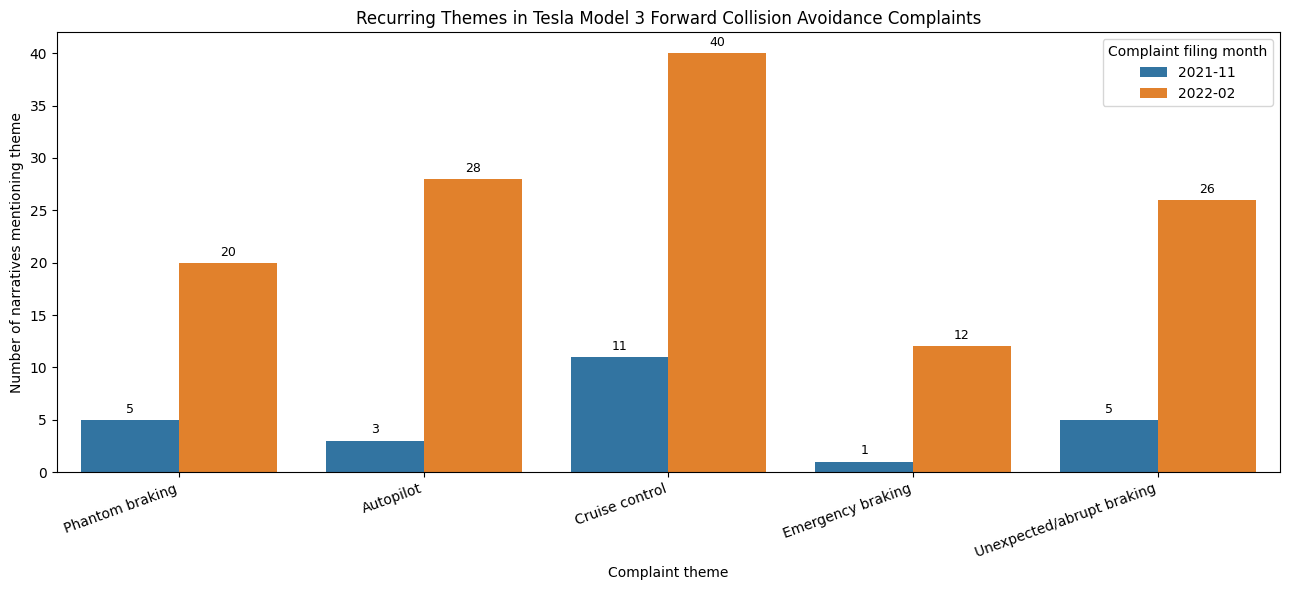

In [22]:
theme_labels = {
    "phantom_braking": "Phantom braking",
    "autopilot": "Autopilot",
    "cruise_control": "Cruise control",
    "emergency_braking": "Emergency braking",
    "unexpected_or_abrupt_braking": "Unexpected/abrupt braking"
}

theme_plot_df = (
    theme_counts_by_month
    .reset_index()
    .melt(
        id_vars="filed_month",
        var_name="theme",
        value_name="narrative_count"
    )
)

theme_plot_df["theme"] = theme_plot_df["theme"].map(theme_labels)

plt.figure(figsize=(13, 6))

ax = sns.barplot(
    data=theme_plot_df,
    x="theme",
    y="narrative_count",
    hue="filed_month"
)

plt.title(
    "Recurring Themes in Tesla Model 3 Forward Collision Avoidance Complaints"
)
plt.xlabel("Complaint theme")
plt.ylabel("Number of narratives mentioning theme")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Complaint filing month")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

plt.tight_layout()
plt.show()